In [2]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

# LOAD DATA

In [3]:
df = pd.read_csv('train.csv')
df.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


# EDA

### Distribusi Label

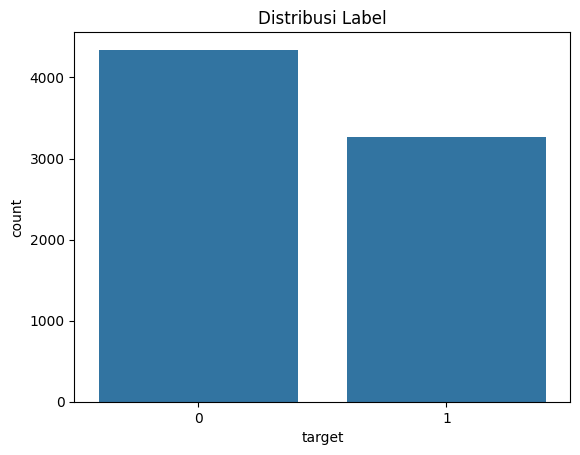

In [4]:
sns.countplot(x='target', data=df)
plt.title('Distribusi Label')
plt.show()

### Panjang Tweet

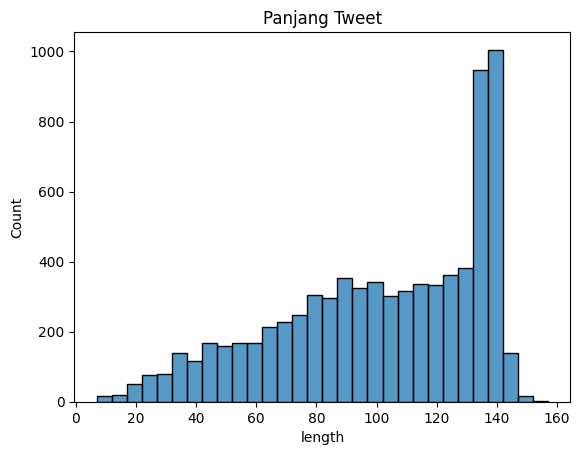

In [5]:
df['length'] = df['text'].apply(len)

sns.histplot(df['length'], bins=30)
plt.title('Panjang Tweet')
plt.show()

# PREPROCESSING

In [6]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

df['clean_text'] = df['text'].apply(clean_text)

# TF-IDF

In [7]:
tfidf = TfidfVectorizer(ngram_range=(1,2), max_features=5000)

X = tfidf.fit_transform(df['clean_text'])
y = df['target']

# SPLIT

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# MODEL KONVENSIONAL

### Logistic Regression

In [9]:
start = time.time()

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

lr_time = time.time() - start

pred_lr = lr.predict(X_test)

print("F1 LR:", f1_score(y_test, pred_lr))
print("Time LR:", lr_time)

F1 LR: 0.75
Time LR: 0.17137670516967773


### Naive Bayes

In [10]:
start = time.time()

nb = MultinomialNB()
nb.fit(X_train, y_train)

nb_time = time.time() - start

pred_nb = nb.predict(X_test)

print("F1 NB:", f1_score(y_test, pred_nb))
print("Time NB:", nb_time)

F1 NB: 0.734982332155477
Time NB: 0.006737470626831055


# DL - LSTM

In [11]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df['clean_text'])

X_seq = tokenizer.texts_to_sequences(df['clean_text'])
X_pad = pad_sequences(X_seq, maxlen=50)

In [12]:
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_pad, y, test_size=0.2, random_state=42
)

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

model = Sequential([
    Embedding(5000, 64),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

In [14]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

start = time.time()

model.fit(X_train_dl, y_train_dl, epochs=5, batch_size=32)

dl_time = time.time() - start

Epoch 1/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.7228 - loss: 0.5484
Epoch 2/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.8488 - loss: 0.3539
Epoch 3/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.8900 - loss: 0.2755
Epoch 4/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.9159 - loss: 0.2221
Epoch 5/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9332 - loss: 0.1856


In [15]:
pred_dl = (model.predict(X_test_dl) > 0.5).astype(int)

print("F1 DL:", f1_score(y_test_dl, pred_dl))
print("Time DL:", dl_time)

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
F1 DL: 0.7051189617880317
Time DL: 43.28915572166443


# ERROR ANALYSIS

In [16]:
wrong = np.where(pred_lr != y_test)[0]

for i in range(3):
    idx = wrong[i]
    print("Text:", df.iloc[idx]['text'])
    print("True:", y_test.iloc[idx])
    print("Pred:", pred_lr[idx])
    print("------")

Text: Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all
True: 1
Pred: 0
------
Text: Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school 
True: 0
Pred: 1
------
Text: #flood #disaster Heavy rain causes flash flooding of streets in Manitou, Colorado Springs areas
True: 1
Pred: 0
------


# FINAL RESULT

In [17]:
print("F1 LR:", f1_score(y_test, pred_lr))
print("F1 NB:", f1_score(y_test, pred_nb))
print("F1 DL:", f1_score(y_test_dl, pred_dl))

print("LR Time:", lr_time)
print("NB Time:", nb_time)
print("DL Time:", dl_time)

F1 LR: 0.75
F1 NB: 0.734982332155477
F1 DL: 0.7051189617880317
LR Time: 0.17137670516967773
NB Time: 0.006737470626831055
DL Time: 43.28915572166443
